# 00 · Démo : vérifier que tout fonctionne

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/00_setup/demo.ipynb)

Ce notebook vérifie ton installation, sur Colab comme sur ton ordinateur. Lance **Exécuter tout** (*Run all*) : il doit aller jusqu'au bout sans erreur.

| Étape | Ce que tu vérifies |
|---|---|
| 1. Setup | Python, les bibliothèques, la graine aléatoire, le device (CPU ou GPU) |
| 2. Datasets | chaque dataset fil rouge se charge, avec un aperçu |
| 3. `wb.check` | une réponse juste passe ✅, une réponse fausse échoue ❌ avec un indice, un exercice pas fait affiche ⏳ |
| 4. mylearn | le mécanisme de ta future librairie et de ses tests |

⏱️ Environ 2 minutes. La **première fois**, compte quelques minutes de plus : Fashion-MNIST (≈ 30 Mo) et CIFAR-10 (≈ 170 Mo) sont téléchargés puis gardés en cache.

## 1. Setup

Chaque notebook du workbook commence par **la même cellule**. Sur Colab, elle monte ton Google Drive, récupère la dernière version du dépôt (`git pull`) ou le clone la première fois, puis appelle `wb.setup()`. En local, elle retrouve simplement le dossier du dépôt.

`FAST_MODE = True` garde des calculs courts (sous-échantillons, peu d'epochs) : c'est le mode par défaut, pensé pour un CPU.

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


> 💡 Le rapport ci-dessus doit afficher tes versions de Python et des bibliothèques. Une ligne ⚠️ signale une version différente de celle du workbook : en général ça marche quand même, mais des résultats peuvent varier légèrement.

## 2. Les datasets fils rouges

Tous les datasets se chargent avec une fonction de `wb.datasets`. Chacun a sa fiche descriptive (*data card*) dans `data/cards/`.

In [2]:
wb.datasets.list_datasets()

,dataset,loader,type,versionné,fiche
0,penguins,wb.datasets.load_penguins(),"tabulaire, classification",oui,data/cards/penguins.md
1,penguins_raw,wb.datasets.load_penguins_raw(),"tabulaire brut, nettoyage",oui,data/cards/penguins.md
2,california_housing,wb.datasets.load_california(),"tabulaire, régression",oui,data/cards/california_housing.md
3,mnist,wb.datasets.load_mnist(),"images 28×28, 10 chiffres",oui,data/cards/mnist.md
4,fashion_mnist,wb.datasets.load_fashion_mnist(),"images 28×28, 10 vêtements",non (téléchargé),data/cards/fashion_mnist.md
5,cifar10,wb.datasets.load_cifar10(),"images couleur 32×32, 10 classes",non (téléchargé),data/cards/cifar10.md
6,holmes,wb.datasets.load_holmes(),texte anglais,oui,data/cards/holmes.md
7,verne,wb.datasets.load_verne(),texte français,oui,data/cards/verne.md
8,sunspots,wb.datasets.load_sunspots(),série temporelle mensuelle,oui,data/cards/sunspots.md
9,synthetic,wb.synth.*,données générées,non (téléchargé),data/cards/synthetic.md


### Palmer Penguins (tabulaire)
344 manchots de 3 espèces. Il y a des valeurs manquantes : c'est voulu, on apprendra à les traiter.

In [3]:
penguins = wb.datasets.load_penguins()
print(penguins.shape)
penguins.head()

(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


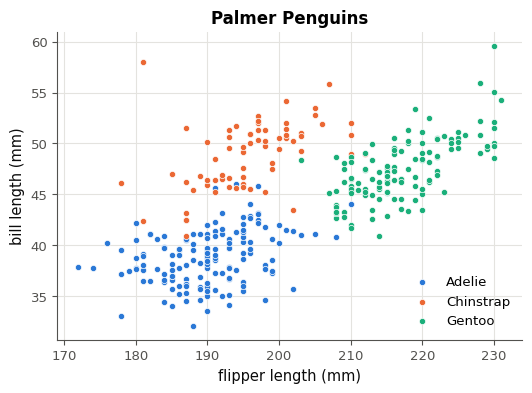

Raw version: (344, 17) -> ['studyName', 'Sample Number', 'Species', 'Region', 'Island', 'Stage'] ...


In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for species, group in penguins.groupby("species"):
    ax.scatter(group["flipper_length_mm"], group["bill_length_mm"], s=20,
               edgecolor="white", linewidth=0.5, label=species)
ax.set_xlabel("flipper length (mm)")
ax.set_ylabel("bill length (mm)")
ax.set_title("Palmer Penguins")
ax.legend()
plt.show()

penguins_raw = wb.datasets.load_penguins_raw()
print("Raw version:", penguins_raw.shape, "->", list(penguins_raw.columns[:6]), "...")

### California Housing (tabulaire, régression)
Prix médian des logements par quartier (recensement de 1990). La cible `MedHouseVal` est en centaines de milliers de dollars.

In [5]:
housing = wb.datasets.load_california()
print(housing.shape)
housing.describe().T.round(2)

(20640, 9)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,20640.0,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,20640.0,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
AveOccup,20640.0,3.07,10.39,0.69,2.43,2.82,3.28,1243.33
Latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,20640.0,2.07,1.15,0.15,1.20,1.80,2.65,5.00


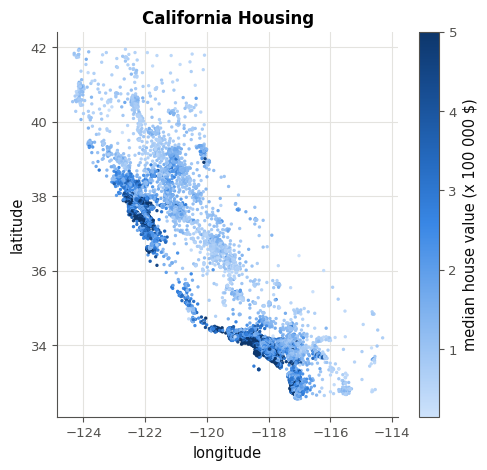

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
points = ax.scatter(housing["Longitude"], housing["Latitude"], c=housing["MedHouseVal"],
                    s=2, cmap=wb.plot.sequential_cmap())
fig.colorbar(points, ax=ax, label="median house value (x 100 000 $)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("California Housing")
plt.show()

### MNIST (images de chiffres, 28 × 28)
Versionné dans le dépôt : aucun téléchargement. En FAST_MODE, on ne charge qu'un sous-échantillon.

(2000, 28, 28) uint8 labels: [5 3 8 1 3 0 4 0 4 1]


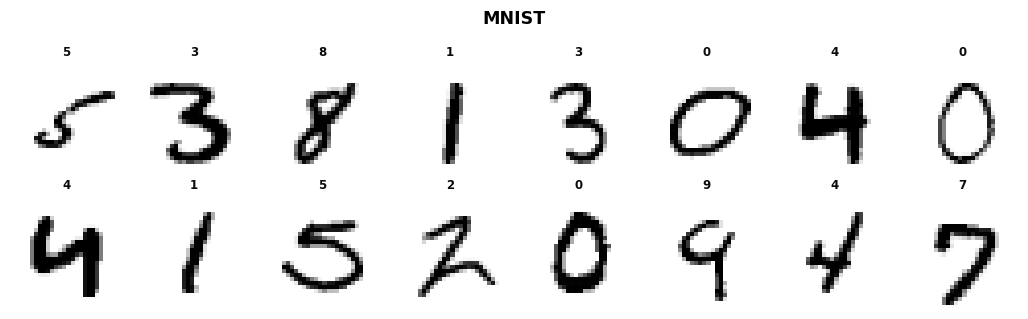

In [7]:
X_mnist, y_mnist = wb.datasets.load_mnist("train", n=wb.by_mode(fast=2000, full=60000))
print(X_mnist.shape, X_mnist.dtype, "labels:", y_mnist[:10])
wb.plot.show_images(X_mnist[:16], labels=y_mnist[:16], ncols=8, title="MNIST")
plt.show()

### Fashion-MNIST (vêtements, 28 × 28)
Téléchargé la première fois (≈ 30 Mo), puis gardé en cache.

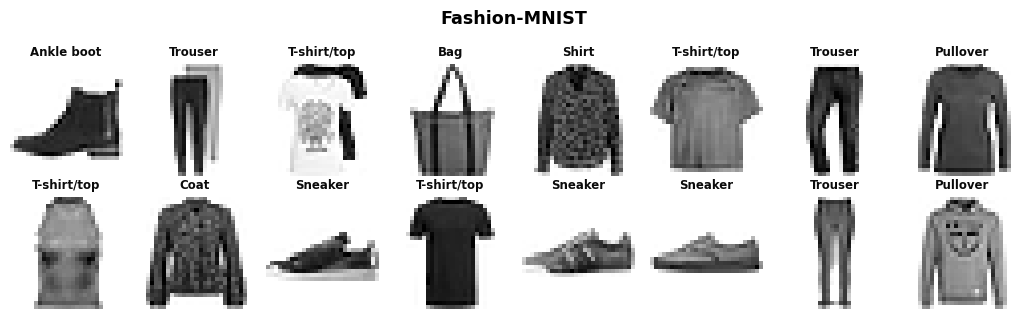

In [8]:
X_fashion, y_fashion = wb.datasets.load_fashion_mnist("test", n=16)
wb.plot.show_images(X_fashion, labels=y_fashion, class_names=wb.datasets.FASHION_CLASSES,
                    ncols=8, title="Fashion-MNIST")
plt.show()

### CIFAR-10 (images couleur, 32 × 32)
Téléchargé la première fois (≈ 170 Mo), puis gardé en cache.

(16, 32, 32, 3) uint8


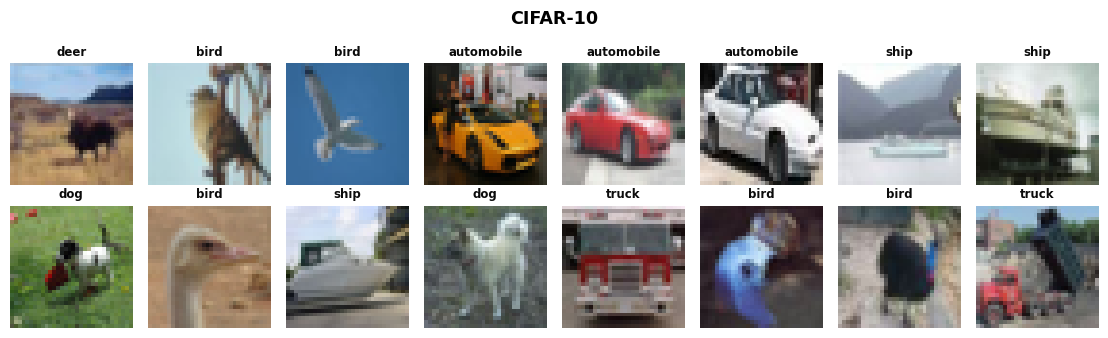

In [9]:
X_cifar, y_cifar = wb.datasets.load_cifar10("test", n=16)
print(X_cifar.shape, X_cifar.dtype)
wb.plot.show_images(X_cifar, labels=y_cifar, class_names=wb.datasets.CIFAR10_CLASSES,
                    ncols=8, size=1.4, title="CIFAR-10")
plt.show()

### Holmes et Verne (textes)
Deux romans du domaine public : l'un en anglais, l'autre en français.

In [10]:
holmes = wb.datasets.load_holmes()
verne = wb.datasets.load_verne()
for name, text in [("Holmes (EN)", holmes), ("Verne (FR)", verne)]:
    print(f"{name}: {len(text):,} characters, {len(text.split()):,} words")
print()
print(holmes[:200])
print("...")
print(verne[:300])

Holmes (EN): 562,203 characters, 104,506 words
Verne (FR): 421,336 characters, 67,412 words

The Adventures of Sherlock Holmes

by Arthur Conan Doyle


Contents

   I.     A Scandal in Bohemia
   II.    The Red-Headed League
   III.   A Case of Identity
   IV.    The Boscombe Valley Mystery
 
...
Jules Verne

LE TOUR DU MONDE EN QUATRE-VINGTS JOURS

(1873)




Table des matières


I DANS LEQUEL PHILEAS FOGG ET PASSEPARTOUT S'ACCEPTENT RÉCIPROQUEMENT
L'UN COMME MAÎTRE, L'AUTRE COMME DOMESTIQUE

II OÙ PASSEPARTOUT EST CONVAINCU QU'IL A ENFIN TROUVE SON IDEAL

III OÙ S'ENGAGE UNE CONVERSATION Q


### Taches solaires (série temporelle)
Nombre moyen de taches solaires chaque mois depuis 1749. On voit le cycle d'environ 11 ans.

(3332, 8) from 1749-01-01 to 2026-08-01


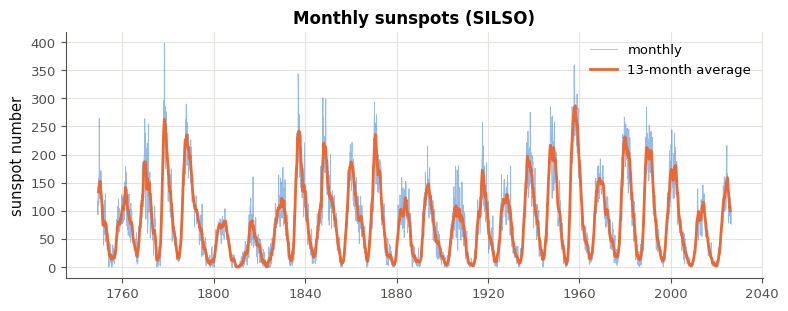

In [11]:
sunspots = wb.datasets.load_sunspots()
print(sunspots.shape, "from", sunspots["date"].min().date(), "to", sunspots["date"].max().date())
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(sunspots["date"], sunspots["sunspots"], linewidth=0.6, alpha=0.5, label="monthly")
ax.plot(sunspots["date"], sunspots["sunspots"].rolling(13, center=True).mean(), label="13-month average")
ax.set_ylabel("sunspot number")
ax.set_title("Monthly sunspots (SILSO)")
ax.legend()
plt.show()

### Données synthétiques
Générées à la demande avec une graine : on contrôle tout (bruit, nombre de points, forme).

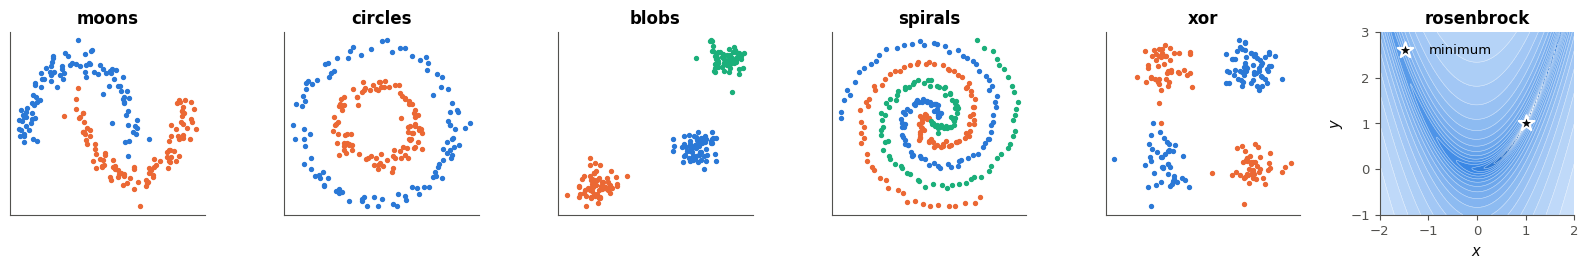

In [12]:
generators = {
    "moons": wb.synth.make_moons(200, noise=0.1),
    "circles": wb.synth.make_circles(200, noise=0.06),
    "blobs": wb.synth.make_blobs(200, centers=3),
    "spirals": wb.synth.make_spirals(300, n_classes=3),
    "xor": wb.synth.make_xor(200),
}
fig, axes = plt.subplots(1, 6, figsize=(16, 2.8))
for ax, (name, (X, y)) in zip(axes, generators.items()):
    for k in range(y.max() + 1):
        ax.scatter(X[y == k, 0], X[y == k, 1], s=8)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
wb.plot.plot_contour(wb.synth.rosenbrock, minimum=(1, 1), ax=axes[5], resolution=150, title="rosenbrock")
fig.tight_layout()
plt.show()

### Environnements d'apprentissage par renforcement

In [13]:
lake = wb.datasets.make_env("FrozenLake-v1", seed=0, is_slippery=False, render_mode="ansi")
print(lake.render())

cartpole = wb.datasets.make_env("CartPole-v1", seed=0)
observation, info = cartpole.reset(seed=0)
steps, done = 0, False
while not done:  # random actions until the pole falls
    observation, reward, terminated, truncated, info = cartpole.step(cartpole.action_space.sample())
    done = terminated or truncated
    steps += 1
print(f"CartPole: the pole fell after {steps} random steps")


SFFF
FHFH
FFFH
HFFG

CartPole: the pole fell after 18 random steps


## 3. Vérifier ses réponses avec `wb.check`

Dans les notebooks d'exercices, tu compares ta réponse à la solution **sans jamais la voir** : `wb.check` compare une empreinte (*hash*) de ta valeur à celle de la solution.

**Ex demo.1** : combien de manchots contient le dataset ?

In [14]:
n_penguins = len(penguins)
wb.check("demo.1", n_penguins)

✅ Ex demo.1 : Exact !


**Ex demo.2** : quelle est la longueur moyenne des nageoires (`flipper_length_mm`), arrondie à 1 décimale, en ignorant les valeurs manquantes ?

Voici d'abord une réponse **fausse**, pour voir le message : il donne une piste sans révéler la réponse.

In [15]:
wrong_answer = penguins["flipper_length_mm"].sum()  # oops: a sum, not a mean
wb.check("demo.2", wrong_answer)

❌ Ex demo.2 : Erreur classique. Piste : tu as calculé une somme ; la moyenne divise par le nombre de valeurs


In [16]:
right_answer = penguins["flipper_length_mm"].mean()  # pandas ignores missing values
wb.check("demo.2", right_answer)

✅ Ex demo.2 : Bien joué !


**Ex demo.3** : quelle espèce a la masse moyenne la plus élevée ? Tant que la réponse vaut `...`, l'exercice est marqué ⏳ (pas encore fait), sans erreur.

In [17]:
heaviest_species = ...  # TODO (try it: penguins.groupby("species")["body_mass_g"].mean())
wb.check("demo.3", heaviest_species)

⏳ Ex demo.3 : pas encore fait (remplace `...` ou `None` par ta réponse).


**Ex demo.4** : une fonction pas encore écrite lève `NotImplementedError`. Le bloc `with wb.attempt(...)` l'affiche comme ⏳ au lieu d'arrêter le notebook : c'est ce qui permet de faire « Exécuter tout » même quand rien n'est rempli.

In [18]:
def count_islands(df):
    """Return the number of distinct islands in the dataset."""
    # TODO: replace the line below with your code
    raise NotImplementedError("count_islands() is not written yet")


with wb.attempt("demo.4"):
    wb.check("demo.4", count_islands(penguins))

⏳ Ex demo.4 : pas encore fait (count_islands() is not written yet).


## 4. mylearn : ta librairie

Au fil des chapitres, tu construis ta propre librairie de machine learning, `mylearn`, dans `mon_travail/mylearn/` (ton espace : Claude n'y écrit jamais). Elle n'existe pas encore : c'est normal.

In [19]:
mylearn = wb.load_mylearn("learner", missing_ok=True)
with wb.attempt("demo.5"):
    print(mylearn._example.mean([1, 2, 3, 4]))

ℹ️ Ta librairie mylearn n'existe pas encore dans mon_travail/mylearn/ ; lance d'abord : python tools/start_chapter.py <chapitre>.
⏳ Ex demo.5 : pas encore fait (ta librairie mylearn n'existe pas encore dans mon_travail/mylearn/ ; lance d'abord : python tools/start_chapter.py <chapitre>).


Une **implémentation de référence** existe dans `solutions/mylearn_ref/` : c'est elle qu'utilisent les notebooks de solutions.

In [20]:
mylearn_ref = wb.load_mylearn("ref", alias="mylearn_ref")
print("reference mean:", mylearn_ref._example.mean([1, 2, 3, 4]))

reference mean: 2.5


Les tests `pytest` comparent chaque fonction de mylearn à une bibliothèque de confiance (ici `numpy.mean`). Le même test tourne sur **ton** code (`--impl=learner`, par défaut) ou sur **la référence** (`--impl=ref`) :

In [21]:
for impl in ["ref", "learner"]:
    result = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_example_mylearn.py", f"--impl={impl}", "-q",
         "-p", "no:cacheprovider", "--color=no"],
        cwd=ROOT, capture_output=True, text=True,
    )
    print(f"--impl={impl}:", result.stdout.strip().splitlines()[-1])

--impl=ref: 5 passed in 0.02s


--impl=learner: 5 skipped in 0.01s


Pour `--impl=learner`, les tests sont ignorés (*skipped*) tant que ta librairie n'existe pas. Pour la créer :

```bash
python tools/start_chapter.py --init
```

Implémente ensuite `mean` dans `mon_travail/mylearn/_example.py`, puis relance `python -m pytest tests/test_example_mylearn.py` : les 5 tests doivent passer.

## ✅ Bilan

Si toutes les cellules ont tourné, ton environnement est prêt :
- [ ] le rapport de setup affiche Python et les bibliothèques ;
- [ ] les 8 datasets et les environnements RL se chargent ;
- [ ] `demo.1` ✅, `demo.2` ❌ puis ✅, `demo.3` et `demo.4` ⏳ ;
- [ ] les tests passent avec `--impl=ref`.

**Pour aller plus loin** : remplace le `...` de demo.3 et écris `count_islands` (demo.4), puis relance les cellules : tu dois obtenir ✅.

Prochaine étape : le syllabus détaillé (`docs/SYLLABUS.md`), puis le chapitre 0A.